<a href="https://colab.research.google.com/github/juanjo9926/INTELIGENCIA-ARTIFICIAL-1/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Precios Mayoristas de Frutas y Hortalizas en Chile 2025
## Laboratorio 01 - Regresión Lineal Múltiple

---

## Descripción del Proyecto

Este laboratorio implementa un modelo de Regresión Lineal Múltiple para predecir el precio promedio ponderado de frutas y hortalizas en los principales mercados mayoristas de Chile durante el año 2025.

El modelo fue entrenado usando dos métodos:
- Descenso por el Gradiente: el modelo aprende iterativamente ajustando sus parámetros hasta minimizar el error de costo.
- Ecuación Normal: calcula los parámetros óptimos directamente con una fórmula matemática.

Adicionalmente se incluye una curva de precision que muestra, en cada iteracion, el porcentaje de predicciones dentro del 10% de error respecto al valor real.

---

## Acerca del Dataset

Nombre: precio_mayorista_fruta-hortaliza_2025.csv

Fuente: Oficina de Estudios y Politicas Agrarias (ODEPA) - Ministerio de Agricultura de Chile

Licencia: CC0 - Dominio Publico

Tamaño: 113,511 registros x 14 columnas

| Columna | Descripcion |
|---|---|
| Fecha | Fecha del registro (2025) |
| ID_Region | Codigo numerico de la region |
| Region | Nombre de la region de Chile |
| Mercado | Nombre del mercado mayorista |
| Subsector | Tipo de producto (frutas o hortalizas) |
| Producto | Nombre del producto (Acelga, Aji, Tomate, etc.) |
| Variedad | Variedad especifica del producto |
| Calidad | Calidad del producto (Primera, Segunda, etc.) |
| Unidad | Unidad de venta (caja, atado, malla, etc.) |
| Origen | Region o provincia de origen del producto |
| Volumen | Cantidad comercializada |
| Precio_Min | Precio minimo registrado en CLP |
| Precio_Max | Precio maximo registrado en CLP |
| Precio_Prom | Variable objetivo (Y) a predecir |

---

## Requisitos del Laboratorio Cumplidos

| Requisito | Valor obtenido |
|---|---|
| n >= 10 variables (features) | 14 variables |
| m >= 20,000 ejemplos | 113,511 ejemplos |
| Uso de libreria Pandas | Carga y preprocesamiento completo |
| Descenso por el Gradiente | Implementado con curva de costo y curva de precision |
| Ecuacion Normal | Implementada y comparada con gradiente |
| Graficas del modelo | 6 graficas generadas |

---

## Resultados Obtenidos

- Costo inicial: 2,538,827,863.53
- Costo final: 34,430.68
- Error promedio absoluto: $31.50 CLP
- Precio real promedio: $26,770.05 CLP
- Precio predicho promedio: $26,770.05 CLP
- Tasa de aprendizaje optima (alpha): 0.1
- Iteraciones: 400

---

## Tecnologias Utilizadas

- Python 3
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Scikit-learn (solo LabelEncoder para preprocesamiento)

In [1]:
# Aquí importamos todas las herramientas que vamos a necesitar


import os
import numpy as np
import pandas as pd  # Para abrir y limpiar el dataset (como Excel pero en Python)
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

ruta = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/precio_mayorista_fruta-hortaliza_2025.csv'

df = pd.read_csv(
    ruta,
    encoding='utf-8-sig',
    sep=',',
    quotechar='"'
)

print("Primeras filas del dataset:")
print(df.head(5))
print(f"\nEl dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")
print("\nNombres de columnas:")
print(df.columns.tolist())

Mounted at /content/gdrive
Primeras filas del dataset:
        Fecha  ID region                Region  \
0  2025-01-02          5  Región de Valparaíso   
1  2025-01-02          8     Región del Biobío   
2  2025-01-02         16       Región de Ñuble   
3  2025-01-02         16       Región de Ñuble   
4  2025-01-02          4    Región de Coquimbo   

                                Mercado                Subsector Producto  \
0                  Femacal de La Calera  Hortalizas y tubérculos   Acelga   
1            Vega Monumental Concepción  Hortalizas y tubérculos   Acelga   
2  Terminal Hortofrutícola Agro Chillán  Hortalizas y tubérculos   Acelga   
3  Terminal Hortofrutícola Agro Chillán  Hortalizas y tubérculos   Acelga   
4      Terminal La Palmera de La Serena  Hortalizas y tubérculos      Ají   

   Variedad / Tipo  Calidad    Unidad de comercializacion  \
0  Sin especificar  Primera  $/docena de atados (6 kilos)   
1  Sin especificar  Primera          $/atado 0,5 a 1 kilo  

In [3]:
# Renombramos columnas
df.columns = ['Fecha', 'ID_Region', 'Region', 'Mercado', 'Subsector',
              'Producto', 'Variedad', 'Calidad', 'Unidad', 'Origen',
              'Volumen', 'Precio_Min', 'Precio_Max', 'Precio_Prom']

# Convertimos fecha
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month
df['Dia'] = df['Fecha'].dt.day

# Convertimos precios
for col in ['Precio_Min', 'Precio_Max', 'Precio_Prom']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Volumen'] = pd.to_numeric(df['Volumen'], errors='coerce')

# Label Encoding
from sklearn.preprocessing import LabelEncoder
columnas_categoricas = ['Region', 'Mercado', 'Subsector', 'Producto',
                        'Variedad', 'Calidad', 'Unidad', 'Origen']
le = LabelEncoder()
for col in columnas_categoricas:
    df[col + '_cod'] = le.fit_transform(df[col].astype(str))

df = df.dropna()

print(f"Dataset limpio: {df.shape[0]} filas y {df.shape[1]} columnas")
print(df.dtypes)
print(df[['Fecha', 'Producto', 'Volumen', 'Precio_Min', 'Precio_Max', 'Precio_Prom']].head())

Dataset limpio: 113511 filas y 24 columnas
Fecha            datetime64[ns]
ID_Region                 int64
Region                   object
Mercado                  object
Subsector                object
Producto                 object
Variedad                 object
Calidad                  object
Unidad                   object
Origen                   object
Volumen                   int64
Precio_Min              float64
Precio_Max              float64
Precio_Prom             float64
Mes                       int32
Dia                       int32
Region_cod                int64
Mercado_cod               int64
Subsector_cod             int64
Producto_cod              int64
Variedad_cod              int64
Calidad_cod               int64
Unidad_cod                int64
Origen_cod                int64
dtype: object
       Fecha Producto  Volumen  Precio_Min  Precio_Max  Precio_Prom
0 2025-01-02   Acelga      110      4000.0      4000.0       4000.0
1 2025-01-02   Acelga      300       80

In [4]:
features = [
    'ID_Region', 'Mes', 'Dia', 'Volumen',
    'Precio_Min', 'Precio_Max',
    'Region_cod', 'Mercado_cod', 'Subsector_cod', 'Producto_cod',
    'Variedad_cod', 'Calidad_cod', 'Unidad_cod', 'Origen_cod'
]

X = df[features].values
y = df['Precio_Prom'].values

m = y.size   # numero de ejemplos de entrenamiento
n = X.shape[1]  # numero de caracteristicas

print(f"Ejemplos de entrenamiento (m): {m}")
print(f"Numero de caracteristicas (n): {n}")
print(f"\n¿Cumple m >= 20000? {m >= 20000}")
print(f"¿Cumple n >= 10?    {n >= 10}")
print(f"\nPrimeras 3 filas de X:")
print(X[:3])
print(f"\nPrimeros 3 valores de y:")
print(y[:3])

Ejemplos de entrenamiento (m): 113511
Numero de caracteristicas (n): 14

¿Cumple m >= 20000? True
¿Cumple n >= 10?    True

Primeras 3 filas de X:
[[5.00e+00 1.00e+00 2.00e+00 1.10e+02 4.00e+03 4.00e+03 5.00e+00 2.00e+00
  1.00e+00 0.00e+00 1.95e+02 4.00e+01 9.70e+01 3.70e+01]
 [8.00e+00 1.00e+00 2.00e+00 3.00e+02 8.00e+02 8.00e+02 7.00e+00 1.10e+01
  1.00e+00 0.00e+00 1.95e+02 4.00e+01 1.00e+00 4.70e+01]
 [1.60e+01 1.00e+00 2.00e+00 2.00e+02 6.00e+02 6.00e+02 6.00e+00 7.00e+00
  1.00e+00 0.00e+00 1.95e+02 4.00e+01 1.00e+00 5.50e+01]]

Primeros 3 valores de y:
[4000.  800.  600.]


In [5]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

# Agregamos columna de unos (para theta0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Forma final de X con columna de unos: {X.shape}")
print("(Debe ser (113511, 15) — 14 features + 1 columna de unos)")

Forma final de X con columna de unos: (113511, 15)
(Debe ser (113511, 15) — 14 features + 1 columna de unos)


In [6]:
def calcularCosto(X, y, theta):
    m = y.size
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

# Probamos con distintos valores de theta (igual que el profe)
for t in [0.0, 0.5, 0.6, 0.7, 0.8, 0.75]:
    theta_test = np.full(X.shape[1], t)
    J = calcularCosto(X, y, theta_test)
    print(f'Con theta = {t} en todos -> Costo calculado = {J:.2f}')

Con theta = 0.0 en todos -> Costo calculado = 2538827863.53
Con theta = 0.5 en todos -> Costo calculado = 2538772746.76
Con theta = 0.6 en todos -> Costo calculado = 2538761723.80
Con theta = 0.7 en todos -> Costo calculado = 2538750700.97
Con theta = 0.8 en todos -> Costo calculado = 2538739678.27
Con theta = 0.75 en todos -> Costo calculado = 2538745189.60


In [7]:
def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

# Inicializamos y entrenamos
theta = np.zeros(X.shape[1])
iterations = 400
alpha = 0.1

theta, J_history = gradientDescent(X, y, theta, alpha, iterations)
print('Theta encontrado por descenso gradiente:')
print(theta)
print(f'\nCosto inicial:  {J_history[0]:,.2f}')
print(f'Costo final:    {J_history[-1]:,.2f}')

Theta encontrado por descenso gradiente:
[ 2.67700543e+04 -2.82382166e+00 -1.46083368e+00 -1.79245475e+00
 -1.76369169e-01  3.30359466e+04  3.30098842e+04 -1.75540955e+00
  2.48767179e-01  5.47128976e-01  3.49829150e-01  3.95245184e-01
 -4.06244520e-01 -1.36091580e+00  2.17658354e-01]

Costo inicial:  1,623,507,900.57
Costo final:    34,430.68


Calculando curva de precision por iteracion...


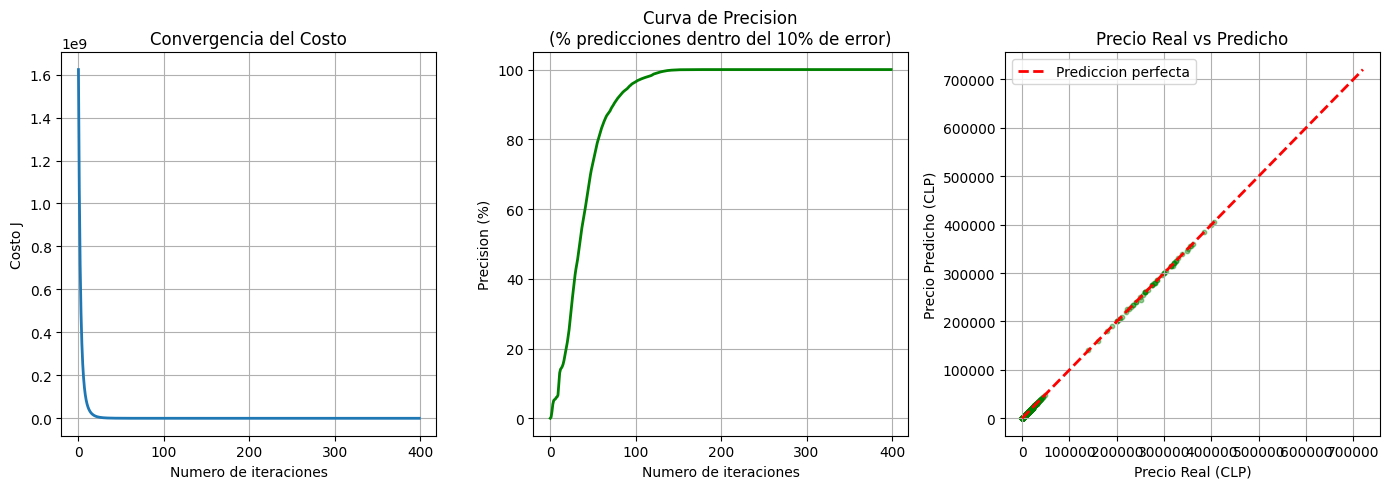


Costo final:     34,430.68
Precision final: 99.99% de predicciones dentro del 10% de error


In [8]:
# Calculamos predicciones y precision por iteracion
y_pred = np.dot(X, theta)

# Tolerancia del 10% para considerar una prediccion "correcta"
tolerancia = 0.10
precision_final = np.mean(np.abs(y_pred - y) / (np.abs(y) + 1e-8) <= tolerancia) * 100

# Calculamos precision en cada iteracion reentrenando paso a paso
print("Calculando curva de precision por iteracion...")
theta_temp = np.zeros(X.shape[1])
precision_history = []

for i in range(iterations):
    theta_temp = theta_temp - (alpha / m) * (np.dot(X, theta_temp) - y).dot(X)
    y_pred_temp = np.dot(X, theta_temp)
    precision = np.mean(np.abs(y_pred_temp - y) / (np.abs(y) + 1e-8) <= tolerancia) * 100
    precision_history.append(precision)

# --- Graficas ---
plt.figure(figsize=(14, 5))

# Grafica 1: Curva de costo
plt.subplot(1, 3, 1)
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Costo')
plt.grid(True)

# Grafica 2: Curva de precision por iteracion
plt.subplot(1, 3, 2)
plt.plot(np.arange(len(precision_history)), precision_history, lw=2, color='green')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Precision (%)')
plt.title('Curva de Precision\n(% predicciones dentro del 10% de error)')
plt.grid(True)

# Grafica 3: Real vs Predicho
plt.subplot(1, 3, 3)
indices = np.random.choice(len(y), 1000, replace=False)
plt.scatter(y[indices], y_pred[indices], alpha=0.4, color='green', s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Prediccion perfecta')
plt.xlabel('Precio Real (CLP)')
plt.ylabel('Precio Predicho (CLP)')
plt.title('Precio Real vs Predicho')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'\nCosto final:     {J_history[-1]:,.2f}')
print(f'Precision final: {precision_final:.2f}% de predicciones dentro del 10% de error')

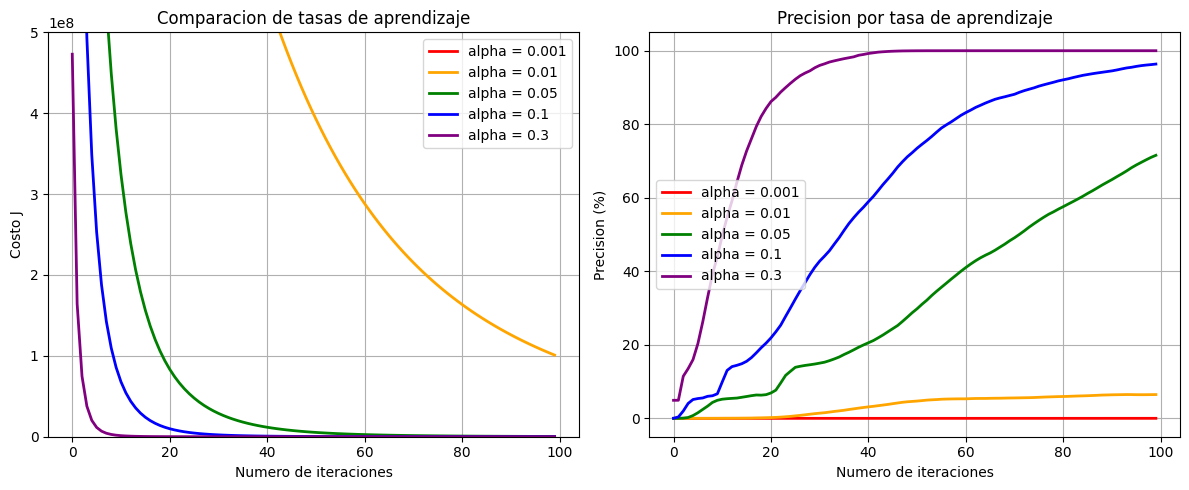

In [9]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.3]
colores = ['red', 'orange', 'green', 'blue', 'purple']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for a, color in zip(alphas, colores):
    theta_temp = np.zeros(X.shape[1])
    _, J_temp = gradientDescent(X, y, theta_temp, a, 100)
    plt.plot(np.arange(len(J_temp)), J_temp, lw=2,
                label=f'alpha = {a}', color=color)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Comparacion de tasas de aprendizaje')
plt.legend()
plt.grid(True)
plt.ylim(0, 500000000)

plt.subplot(1, 2, 2)
for a, color in zip(alphas, colores):
    theta_temp = np.zeros(X.shape[1])
    prec_temp = []
    for i in range(100):
        theta_temp = theta_temp - (a / m) * (np.dot(X, theta_temp) - y).dot(X)
        y_p = np.dot(X, theta_temp)
        prec_temp.append(np.mean(np.abs(y_p - y) / (np.abs(y) + 1e-8) <= tolerancia) * 100)
    plt.plot(np.arange(100), prec_temp, lw=2,
                label=f'alpha = {a}', color=color)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Precision (%)')
plt.title('Precision por tasa de aprendizaje')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
nuevo_ejemplo = np.array([
    13, 3, 15, 200, 8000, 12000, 5, 8, 0, 10, 3, 0, 2, 6
], dtype=float)

nuevo_normalizado = (nuevo_ejemplo - mu) / sigma
nuevo_con_uno = np.concatenate([[1], nuevo_normalizado])
precio_predicho = np.dot(nuevo_con_uno, theta)

print(f'Para una Region=Metropolitana, Mes=Marzo, Volumen=200')
print(f'Precio promedio ponderado predicho: ${precio_predicho:,.2f} CLP')

print(f'\nPrecios reales de referencia:')
muestra = df[['Producto', 'Calidad', 'Volumen', 'Precio_Prom']].sample(5, random_state=42)
print(muestra.to_string(index=False))

Para una Region=Metropolitana, Mes=Marzo, Volumen=200
Precio promedio ponderado predicho: $9,980.76 CLP

Precios reales de referencia:
 Producto        Calidad  Volumen  Precio_Prom
 Nectarín        Primera       12     327500.0
Mandarina        Primera        3     315000.0
    Limón    1a plateado       20     630000.0
  Ciruela        Primera       80      10000.0
  Plátano Primera Pintón      300      23000.0


In [11]:
X_normal = df[features].values
X_normal = np.concatenate([np.ones((X_normal.shape[0], 1)), X_normal], axis=1)

def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

print("Calculando con ecuacion normal")
theta_normal = normalEqn(X_normal, y)

ejemplo_normal = np.concatenate([[1], nuevo_ejemplo])
precio_normal = np.dot(ejemplo_normal, theta_normal)

print(f'\nPrecio predicho con Ecuacion Normal:    ${precio_normal:,.2f} CLP')
print(f'Precio predicho con Descenso Gradiente: ${precio_predicho:,.2f} CLP')
print(f'\n(Si los valores son parecidos, ambos metodos funcionaron bien)')

Calculando con ecuacion normal

Precio predicho con Ecuacion Normal:    $9,974.31 CLP
Precio predicho con Descenso Gradiente: $9,980.76 CLP

(Si los valores son parecidos, ambos metodos funcionaron bien)


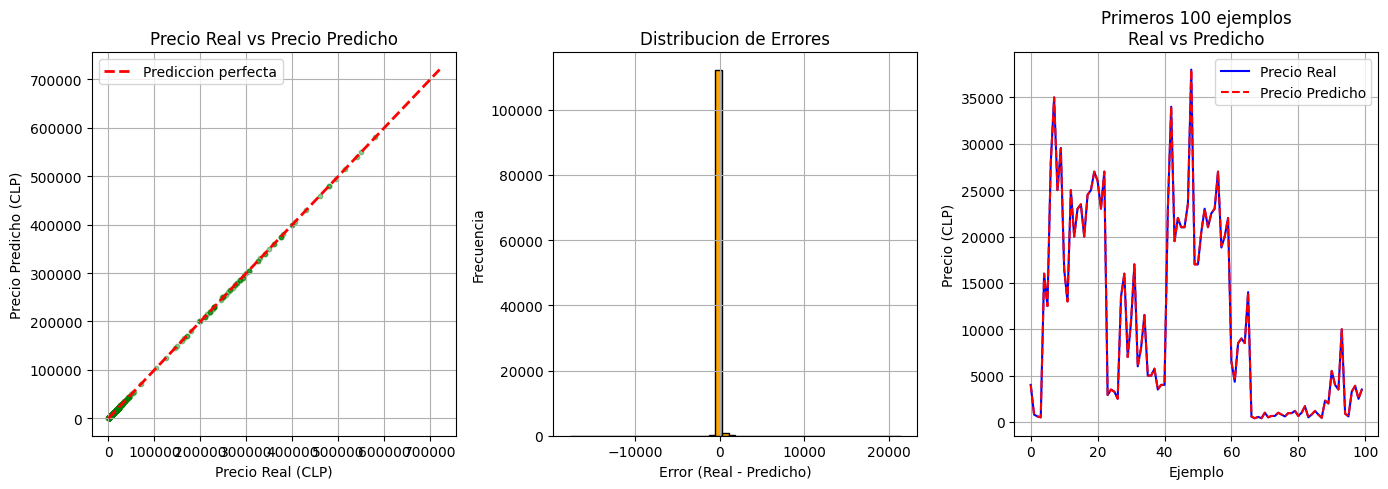

Resumen del modelo:
  Costo final:             34,430.68
  Error promedio absoluto: $31.50 CLP
  Precio real promedio:    $26,770.05 CLP
  Precio predicho promedio:$26,770.05 CLP


In [12]:
y_predicho = np.dot(X, theta)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
indices = np.random.choice(len(y), 1000, replace=False)
plt.scatter(y[indices], y_predicho[indices], alpha=0.4, color='green', s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Prediccion perfecta')
plt.xlabel('Precio Real (CLP)')
plt.ylabel('Precio Predicho (CLP)')
plt.title('Precio Real vs Precio Predicho')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
errores = y - y_predicho
plt.hist(errores, bins=50, color='orange', edgecolor='black')
plt.xlabel('Error (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribucion de Errores')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(y[:100], color='blue', label='Precio Real', lw=1.5)
plt.plot(y_predicho[:100], color='red', label='Precio Predicho', lw=1.5, linestyle='--')
plt.xlabel('Ejemplo')
plt.ylabel('Precio (CLP)')
plt.title('Primeros 100 ejemplos\nReal vs Predicho')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

error_promedio = np.mean(np.abs(errores))
print(f"Resumen del modelo:")
print(f"  Costo final:             {J_history[-1]:,.2f}")
print(f"  Error promedio absoluto: ${error_promedio:,.2f} CLP")
print(f"  Precio real promedio:    ${np.mean(y):,.2f} CLP")
print(f"  Precio predicho promedio:${np.mean(y_predicho):,.2f} CLP")